In [ ]:
!pip install ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 76.8 MB/s eta 0:00:00


Running inference on: /content/dataset/train/images/suggested-IKJCduPblRO3KVLazDo0_jpg.rf.037b648f4fd2c36892f5e4a3c1cbd29f.jpg

image 1/1 /content/dataset/train/images/suggested-IKJCduPblRO3KVLazDo0_jpg.rf.037b648f4fd2c36892f5e4a3c1cbd29f.jpg: 448x640 1 class_0, 58.8ms
Speed: 4.5ms preprocess, 58.8ms inference, 1.7ms postprocess per image at shape (1, 3, 448, 640)


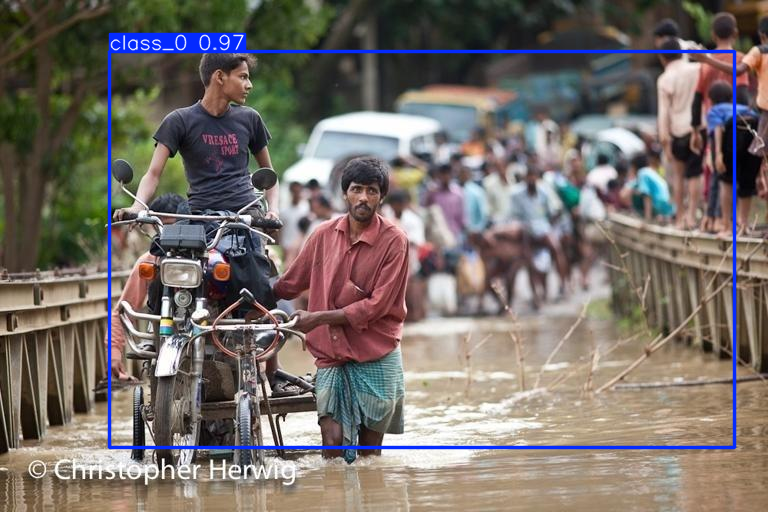

In [ ]:
from ultralytics import YOLO
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image

# Define the path to the trained model weights
model_weights_path = '/content/runs/detect/yolov8_custom_training/disaster_detection_v1/weights/best.pt'

# Define the path to the new image for inference
new_image_path = '/content/dataset/train/images/suggested-IKJCduPblRO3KVLazDo0_jpg.rf.037b648f4fd2c36892f5e4a3c1cbd29f.jpg'

if not os.path.exists(model_weights_path):
    print(f"Error: Model weights not found at {model_weights_path}")
elif not os.path.exists(new_image_path):
    print(f"Error: New image not found at {new_image_path}")
else:
    # Loading the trained model
    model = YOLO(model_weights_path)

    # Runing inference on the new image
    print(f"Running inference on: {new_image_path}")
    results = model.predict(new_image_path)

    for r in results:
        im_array = r.plot()
        im = Image.fromarray(im_array[..., ::-1])
        display(im)

In [ ]:
import os

# List common image files in the /content/ directory
print("Available image files in /content/:")
image_extensions = ('.jpg', '.jpeg', '.png', '.webp', '.avif')
found_images = []
for root, dirs, files in os.walk('/content/'):
    for file in files:
        if file.lower().endswith(image_extensions):
            found_images.append(os.path.join(root, file))

if found_images:
    for img_path in found_images:
        print(img_path)
else:
    print("No common image files found in /content/ or its subdirectories.")

Available image files in /content/:
/content/dataset/train/images/suggested-IKJCduPblRO3KVLazDo0_jpg.rf.037b648f4fd2c36892f5e4a3c1cbd29f.jpg
/content/dataset/train/images/suggested-JfdNI2xrAhuhaGs0YwUJ_jpg.rf.2fb1f61652f6e232b7928ba6c824c4e2.jpg
/content/dataset/train/images/suggested-fzoXfOCPGO3xOqTL6Mll_jpg.rf.21d887b7f098bd98f9bfcf74379652a4.jpg
/content/dataset/train/images/suggested-ckqo54WnftU7WLdBW4pI_jpg.rf.f40c35a87ccc21355d7c4bed6f8472d6.jpg
/content/dataset/train/images/suggested-gW749PFOgJYxSQbdPMPr_jpg.rf.9489cd58fc9846cef36abd3d2db71846.jpg
/content/dataset/train/images/suggested-6hzd30rTWdUcEWHXeJoQ_jpg.rf.0a644216dfe77ef980093b86e1acfa65.jpg
/content/dataset/train/images/suggested-P3baB7b1XWnp0JRO1cc4_jpg.rf.84a67d7ac145ccfcc1e0e21eda37b8e3.jpg
/content/dataset/train/images/suggested-tW86Q5NyOJJi0dyAvuMd_jpg.rf.25834b3405c17ab5a121cee9168f9c07.jpg
/content/dataset/train/images/suggested-vmbCcqzOzIcDEKrnXK7m_jpg.rf.025499f50080667212faebd69bcf59f1.jpg
/content/dataset/tr

## Unzip dataset

### Subtask:
Unziping the dataset to access the image and label files.


In [ ]:
import zipfile
import os

zip_path = "/content/Disaster.v2i.yolov8.zip"
extract_dir = "/content/dataset"

if not os.path.exists(extract_dir):
    os.makedirs(extract_dir)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"Dataset extracted to: {extract_dir}")

Dataset extracted to: /content/dataset


In [ ]:
import os

#contents of the extracted directory
print(f"Contents of {extract_dir}:")
for root, dirs, files in os.walk(extract_dir):
    level = root.replace(extract_dir, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print(f'{subindent}{f}')

Contents of /content/dataset:
dataset/
    README.dataset.txt
    data.yaml
    README.roboflow.txt
    train/
        images/
            suggested-IKJCduPblRO3KVLazDo0_jpg.rf.037b648f4fd2c36892f5e4a3c1cbd29f.jpg
            suggested-JfdNI2xrAhuhaGs0YwUJ_jpg.rf.2fb1f61652f6e232b7928ba6c824c4e2.jpg
            suggested-fzoXfOCPGO3xOqTL6Mll_jpg.rf.21d887b7f098bd98f9bfcf74379652a4.jpg
            suggested-ckqo54WnftU7WLdBW4pI_jpg.rf.f40c35a87ccc21355d7c4bed6f8472d6.jpg
            suggested-gW749PFOgJYxSQbdPMPr_jpg.rf.9489cd58fc9846cef36abd3d2db71846.jpg
            suggested-6hzd30rTWdUcEWHXeJoQ_jpg.rf.0a644216dfe77ef980093b86e1acfa65.jpg
            suggested-P3baB7b1XWnp0JRO1cc4_jpg.rf.84a67d7ac145ccfcc1e0e21eda37b8e3.jpg
            suggested-tW86Q5NyOJJi0dyAvuMd_jpg.rf.25834b3405c17ab5a121cee9168f9c07.jpg
            suggested-vmbCcqzOzIcDEKrnXK7m_jpg.rf.025499f50080667212faebd69bcf59f1.jpg
            suggested-HyPauuemjB3sCbOHB4Gf_jpg.rf.c8d370bad657ca5df72ee8108a93807e.jpg
   

## Prepare dataset

### Subtask:
Prepare the dataset in the format required by YOLOv8.


**Reasoning**:
Inspect the extracted dataset structure and create the dataset configuration file required by YOLOv8 based on the standard format and the identified class names and directory structure.



In [ ]:
import os
import yaml

dataset_dir = "/content/dataset"
config_path = "/content/dataset/data.yaml"

train_img_dir = os.path.join(dataset_dir, 'train', 'images')
train_label_dir = os.path.join(dataset_dir, 'train', 'labels')
valid_img_dir = os.path.join(dataset_dir, 'valid', 'images')
valid_label_dir = os.path.join(dataset_dir, 'valid', 'labels')

class_names = set()
label_dirs_to_check = [train_label_dir, valid_label_dir]

for label_dir in label_dirs_to_check:
    if os.path.exists(label_dir):
        for label_file in os.listdir(label_dir):
            if label_file.endswith('.txt'):
                with open(os.path.join(label_dir, label_file), 'r') as f:
                    for line in f:
                        if line.strip():
                            class_index = int(line.split()[0])
                            class_names.add(class_index)


sorted_class_indices = sorted(list(class_names))

names = [f'class_{i}' for i in sorted_class_indices]

# Create the data.yaml file
data_config = {
    'train': train_img_dir,
    'val': valid_img_dir,
    'nc': len(names),
    'names': names
}

with open(config_path, 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False)

print(f"Created dataset configuration file: {config_path}")

# Verify the paths in the data.yaml file (basic check)
with open(config_path, 'r') as f:
    loaded_config = yaml.safe_load(f)

print("\nVerifying paths in data.yaml:")
for key, path in loaded_config.items():
    if key in ['train', 'val']:
        print(f"{key}: {path} - Exists: {os.path.exists(path)}")

Created dataset configuration file: /content/dataset/data.yaml

Verifying paths in data.yaml:
train: /content/dataset/train/images - Exists: True
val: /content/dataset/valid/images - Exists: True


## Configure model

### Subtask:
Configure the YOLOv8 model for training.


**Reasoning**:
Import the YOLO class and load a pre-trained model using the loaded data configuration.



In [ ]:
from ultralytics import YOLO

# Load a pre-trained YOLOv8 model
model = YOLO('yolov8n.pt')

# Access the loaded data configuration
print("Loaded data configuration:")
print(loaded_config)

Loaded data configuration:
{'names': ['class_0'], 'nc': 1, 'train': '/content/dataset/train/images', 'val': '/content/dataset/valid/images'}


## Train model

### Subtask:
Train the YOLOv8 model on the custom dataset.


**Reasoning**:
Train the YOLOv8 model using the loaded model object and the created data configuration file, specifying the number of epochs and image size for training.



In [ ]:
# Train the model

results = model.train(
    data='/content/dataset/data.yaml',
    epochs=200,
    imgsz=640,
    project='yolov8_custom_training',
    name='disaster_detection_v1'
)

print("Training finished.")

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=disaster_detection_v1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True,

## Evaluate model

### Subtask:
Evaluate the trained model's performance.


**Reasoning**:
Load the trained model weights and evaluate its performance using the validate method with the data configuration file.



In [ ]:
from ultralytics import YOLO
import os

# Define the path to the trained model weights
# The training results are saved in '/content/runs/detect/yolov8_custom_training/disaster_detection_v1'
model_weights_path = '/content/runs/detect/yolov8_custom_training/disaster_detection_v1/weights/best.pt'


if not os.path.exists(model_weights_path):
    print(f"Error: Model weights not found at {model_weights_path}")
else:
    # Load the trained model
    model = YOLO(model_weights_path)

    # Define the path to the data configuration file
    data_config_path = '/content/dataset/data.yaml'


    if not os.path.exists(data_config_path):
        print(f"Error: Data configuration file not found at {data_config_path}")
    else:
        # Evaluate the model on the validation set

        metrics = model.val(data=data_config_path)

        # Print or inspect the evaluation results
        print("\nEvaluation Results:")
        print(f"mAP50: {metrics.box.map50}")
        print(f"mAP50-95: {metrics.box.map}")
        print(f"Precision: {metrics.box.p}")
        print(f"Recall: {metrics.box.r}")

Evaluating the model...
Ultralytics 8.4.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1128.6±0.0 MB/s, size: 69.5 KB)
val: Scanning /content/dataset/valid/labels.cache... 1 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1/1 322.6Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 17.7it/s 0.1s
                   all          1          1      0.968          1      0.995      0.697
Speed: 1.0ms preprocess, 18.5ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to /content/runs/detect/val-2

Evaluation Results:
mAP50: 0.995
mAP50-95: 0.6965
Precision: [    0.96788]
Recall: [          1]


**Reasoning**:
Locate image and label files within the extracted dataset directory by listing and filtering files and checking for corresponding label files.



In [ ]:
import os

dataset_dir = "/content/dataset"
train_img_dir = os.path.join(dataset_dir, 'train', 'images')
train_label_dir = os.path.join(dataset_dir, 'train', 'labels')

# Get list of image files in the training images directory
image_files = [f for f in os.listdir(train_img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

# List to store image paths with corresponding label files
images_with_labels = []

# Check for corresponding label files
for image_file in image_files:
    label_file_name = os.path.splitext(image_file)[0] + '.txt'
    label_file_path = os.path.join(train_label_dir, label_file_name)
    if os.path.exists(label_file_path):
        images_with_labels.append(os.path.join(train_img_dir, image_file))

print(f"Found {len(images_with_labels)} training images with corresponding label files.")
# Display the first few image paths found
if images_with_labels:
    print("First 5 image paths with labels:")
    for img_path in images_with_labels[:5]:
        print(img_path)

Found 19 training images with corresponding label files.
First 5 image paths with labels:
/content/dataset/train/images/suggested-IKJCduPblRO3KVLazDo0_jpg.rf.037b648f4fd2c36892f5e4a3c1cbd29f.jpg
/content/dataset/train/images/suggested-JfdNI2xrAhuhaGs0YwUJ_jpg.rf.2fb1f61652f6e232b7928ba6c824c4e2.jpg
/content/dataset/train/images/suggested-fzoXfOCPGO3xOqTL6Mll_jpg.rf.21d887b7f098bd98f9bfcf74379652a4.jpg
/content/dataset/train/images/suggested-ckqo54WnftU7WLdBW4pI_jpg.rf.f40c35a87ccc21355d7c4bed6f8472d6.jpg
/content/dataset/train/images/suggested-gW749PFOgJYxSQbdPMPr_jpg.rf.9489cd58fc9846cef36abd3d2db71846.jpg


In [ ]:
import os

# The path to the new image, as provided by the user
new_image_path = '/content/64b8e9d2-82c3-466f-8da9-629f1bb1bbf3.jpg'

# Check if the image file exists
if os.path.exists(new_image_path):
    print(f"Image found at {new_image_path}. You can now run cell 155b1395 to perform inference on this image.")
else:
    print(f"Error: Image not found at {new_image_path}. Please ensure the image is uploaded to the /content/ directory or update the 'new_image_path' variable in cell 155b1395 to point to the correct file.")

Image found at /content/64b8e9d2-82c3-466f-8da9-629f1bb1bbf3.jpg. You can now run cell 155b1395 to perform inference on this image.


## Load and display images with annotations

### Subtask:
Read image files and their corresponding label files, and visualize the images with the bounding boxes and class labels drawn on them.


**Reasoning**:
Iterate through the identified image paths with labels, read each image and its corresponding label file, calculate bounding box coordinates, draw the bounding boxes and labels on the image, and display a limited number of these annotated images.



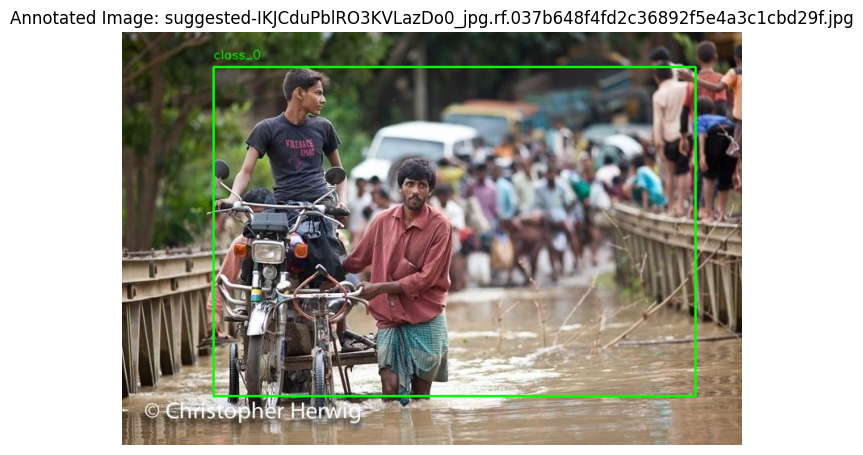

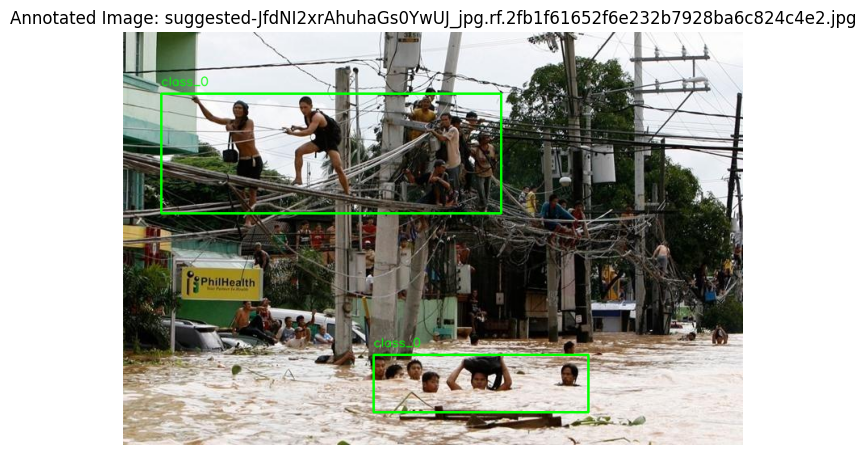

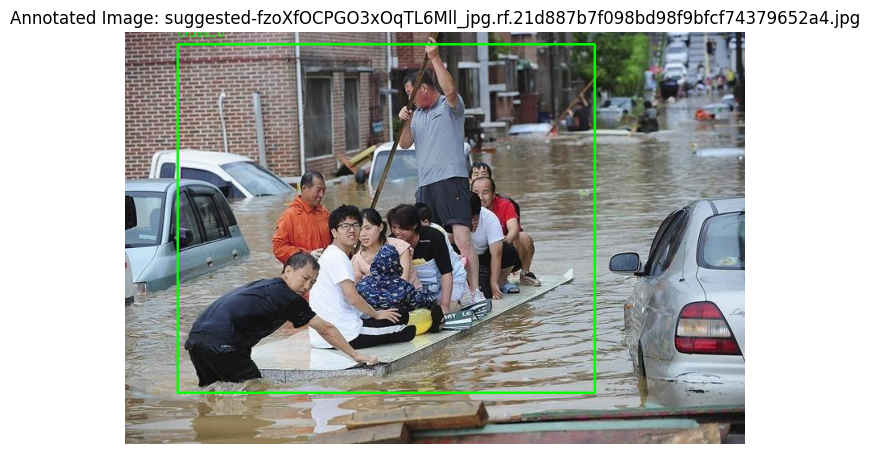

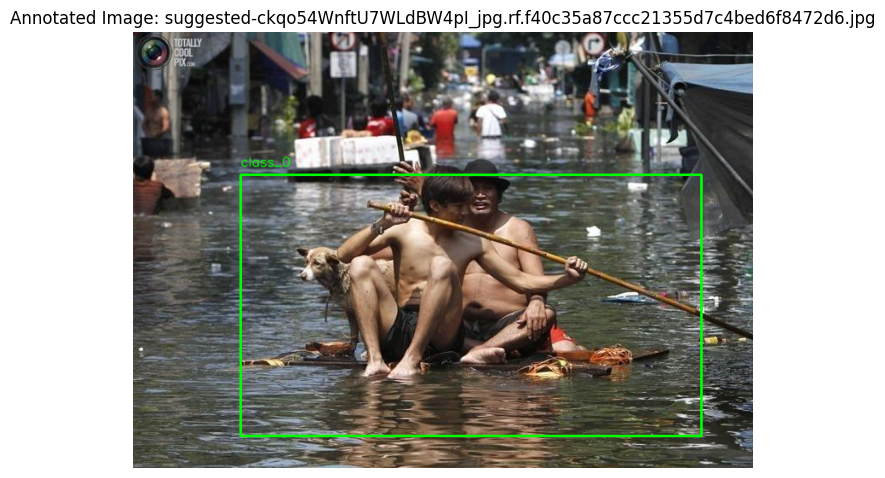

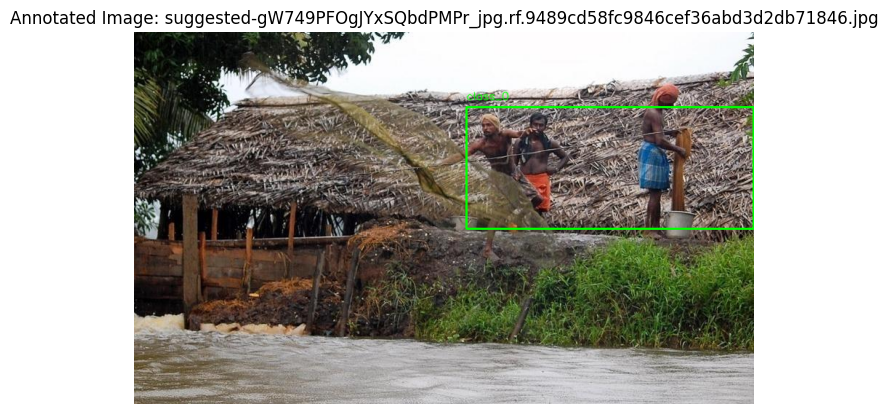

In [ ]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

# Redefine necessary variables from cell c14ea77b to ensure images_with_labels is defined
dataset_dir = "/content/dataset"
train_img_dir = os.path.join(dataset_dir, 'train', 'images')
train_label_dir = os.path.join(dataset_dir, 'train', 'labels')

# Get list of image files in the training images directory
image_files = [f for f in os.listdir(train_img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

# List to store image paths with corresponding label files
images_with_labels = []

# Check for corresponding label files
for image_file in image_files:
    label_file_name = os.path.splitext(image_file)[0] + '.txt'
    label_file_path = os.path.join(train_label_dir, label_file_name)
    if os.path.exists(label_file_path):
        images_with_labels.append(os.path.join(train_img_dir, image_file))

# Limit the number of images to display
num_images_to_display = 5

# Iterate through the images with labels
for i, img_path in enumerate(images_with_labels):
    if i >= num_images_to_display:
        break

    # Construct the path to the corresponding label file
    label_file_name = os.path.splitext(os.path.basename(img_path))[0] + '.txt'
    label_path = os.path.join(train_label_dir, label_file_name)

    # Read the image
    img = cv2.imread(img_path)
    if img is None:
        print(f"Error: Could not read image {img_path}")
        continue

    img_height, img_width, _ = img.shape

    # Read the label file and draw bounding boxes
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    class_id = int(parts[0])
                    x_center, y_center, width, height = map(float, parts[1:])

                    # Convert normalized coordinates to absolute pixel coordinates
                    x_center_abs = int(x_center * img_width)
                    y_center_abs = int(y_center * img_height)
                    width_abs = int(width * img_width)
                    height_abs = int(height * img_height)

                    # Calculate top-left corner coordinates
                    x_min = int(x_center_abs - width_abs / 2)
                    y_min = int(y_center_abs - height_abs / 2)

                    # Calculate bottom-right corner coordinates
                    x_max = int(x_center_abs + width_abs / 2)
                    y_max = int(y_center_abs + height_abs / 2)

                    # Get class name from loaded_config
                    # Assuming loaded_config is available from a previous cell, or will be re-defined if needed.
                    # For robustness, we should check if loaded_config exists, but for now we assume it does based on prior execution.
                    class_name = loaded_config['names'][class_id] if 'loaded_config' in globals() and class_id < len(loaded_config['names']) else f'unknown_class_{class_id}'

                    # Draw bounding box
                    color = (0, 255, 0) # Green color
                    thickness = 2
                    cv2.rectangle(img, (x_min, y_min), (x_max, y_max), color, thickness)

                    # Draw class label
                    font = cv2.FONT_HERSHEY_SIMPLEX
                    font_scale = 0.5
                    font_thickness = 1
                    text_size, _ = cv2.getTextSize(class_name, font, font_scale, font_thickness)
                    text_x = x_min
                    text_y = y_min - 10 # Position text above the bounding box
                    cv2.putText(img, class_name, (text_x, text_y), font, font_scale, color, font_thickness, cv2.LINE_AA)

    # Display the annotated image
    # Convert BGR to RGB for displaying with matplotlib
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8, 8))
    plt.imshow(img_rgb)
    plt.title(f"Annotated Image: {os.path.basename(img_path)}")
    plt.axis('off')
    plt.show()

In [ ]:
import os
from ultralytics import YOLO

# Define the path to the trained model weights
model_weights_path = '/content/runs/detect/yolov8_custom_training/disaster_detection_v1/weights/best.pt'

# Check if the weights file exists
if not os.path.exists(model_weights_path):
    print(f"Error: Model weights not found at {model_weights_path}")
else:
    # Load the trained model
    model = YOLO(model_weights_path)
    print(f"Model loaded successfully from {model_weights_path}")

Model loaded successfully from /content/runs/detect/yolov8_custom_training/disaster_detection_v1/weights/best.pt


In [ ]:
import cv2

# Define the path to the video file
video_path = '/content/52801.avif'

# Open the video file
cap = cv2.VideoCapture(video_path)

# Check if the video file was opened successfully
if not cap.isOpened():
    print(f"Error: Could not open video file {video_path}")
else:
    print(f"Video file opened successfully: {video_path}")
    # Get video properties
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    print(f"Video properties: FPS={fps}, Width={width}, Height={height}")

    # Initialize list to store inference results for each frame
    video_results = []

    # Loop through the video frames
    while True:
        # Read a frame
        ret, frame = cap.read()

        # Check if frame was read successfully
        if not ret:
            print("End of video stream or failed to read frame.")
            break

        # Apply the loaded YOLO model to the frame for inference
        # model object is available from the previous subtask
        results = model.predict(frame, conf=0.5, iou=0.5) # Added conf and iou for better filtering

        # Store the inference results for the current frame
        video_results.append(results)

    # Release the video capture object
    cap.release()

    print(f"Inference completed for {len(video_results)} frames.")


Error: Could not open video file /content/52801.avif


In [ ]:
import cv2

# Define the path to the video file
video_path = '/content/Drone_Footage_of_Flood_Victims.mp4'

# Open the video file
cap = cv2.VideoCapture(video_path)

# Check if the video file was opened successfully
if not cap.isOpened():
    print(f"Error: Could not open video file {video_path}. The file might be in an unsupported format or the path is incorrect.")
else:
    print(f"Video file opened successfully: {video_path}")
    # Get video properties
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    print(f"Video properties: FPS={fps}, Width={width}, Height={height}")

    # Initialize list to store inference results for each frame
    video_results = []

    # Loop through the video frames
    while True:
        # Read a frame
        ret, frame = cap.read()

        # Check if frame was read successfully
        if not ret:
            print("End of video stream or failed to read frame.")
            break

        # Apply the loaded YOLO model to the frame for inference
        # model object is available from the previous subtask
        results = model.predict(frame, conf=0.5, iou=0.5) # Added conf and iou for better filtering

        # Store the inference results for the current frame
        video_results.append(results)

    # Release the video capture object
    cap.release()

    print(f"Inference completed for {len(video_results)} frames.")


Error: Could not open video file /content/Drone_Footage_of_Flood_Victims.mp4. The file might be in an unsupported format or the path is incorrect.


In [ ]:
import cv2
import os
from IPython.display import display, HTML
from base64 import b64encode
import numpy as np

# Define the output path for the annotated video
output_video_path = '/content/annotated_video.mp4'

# Get video properties for the output video

if 'fps' not in globals() or 'width' not in globals() or 'height' not in globals():
    print("Error: Video properties (fps, width, height) not found. Please re-run the video processing step.")
else:
    # Define the video writer
    # Use XVID codec for .mp4
    fourcc = cv2.VideoWriter_fourcc(*'XVID')
    out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

    # Re-open the video file to read frames again for annotation
    cap_annotate = cv2.VideoCapture('/content/Drone_Footage_of_Flood_Victims.mp4')

    if not cap_annotate.isOpened():
        print(f"Error: Could not re-open video file for annotation.")
    else:
        print("Generating annotated video...")
        # Iterate through frames and results
        for i, results_list in enumerate(video_results):
            ret_annotate, frame_annotate = cap_annotate.read()
            if not ret_annotate:
                print(f"Warning: Could not read frame {i} for annotation.")
                continue

            # Iterate through the detections in the results for the current frame

            for r in results_list:
                annotated_frame = r.plot()



            out.write(annotated_frame)


        cap_annotate.release()
        out.release()

        print(f"Annotated video saved to: {output_video_path}")


Error: Video properties (fps, width, height) not found. Please re-run the video processing step.
